# Fixed-Point Sum Error

Compare the relative error of summing a vector via:
- **fp16** accumulation
- **fp32** accumulation
- **fp64** accumulation
- **fixed-point int16 (Q7.8)** — quantise to int16 with 8 fractional bits, sum in int64, convert back
- **fixed-point int32 (Q15.16)** — quantise to int32 with 16 fractional bits, sum in int64, convert back
- **fixed-point int64 (Q31.32)** — quantise to int64 with 32 fractional bits, sum in int64, convert back

Ground truth is the fp64 Kahan sum. Each point is the **median** relative error over 50 trials.

Solid lines = floating point, dashed lines = fixed point. Matching colours pair types with the same bitwidth (16, 32, 64).

In [44]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath("../../tests/triton_kernels"))

import numpy as np
import torch
import matplotlib.pyplot as plt
from fixed_point_helpers import f2x

In [45]:
SIZES = [64, 256, 1024, 4096, 16384, 65536]
N_TRIALS = 50


def ground_truth(x):
    """Kahan sum in fp64 for a more accurate reference than naive fp64 sum."""
    vals = x.to(torch.float64).cpu().numpy()
    s = 0.0
    c = 0.0
    for v in vals:
        y = float(v) - c
        t = s + y
        c = (t - s) - y
        s = t
    return s


def fp_sum(x, dtype):
    return x.to(dtype).sum().item()


def fx_sum(x, frac_bits, int_dtype):
    """Quantise elements, accumulate in int64 (overflow-safe), scale back."""
    q = f2x(x, frac_bits, int_dtype).to(torch.int64)
    return q.sum().item() * (2.0**-frac_bits)


# ── method definitions: (label, function, family, bitwidth) ──────────
METHODS = [
    ("fp16 sum",             lambda x: fp_sum(x, torch.float16),  "fp", 16),
    ("fp32 sum",             lambda x: fp_sum(x, torch.float32),  "fp", 32),
    ("fp64 sum",             lambda x: fp_sum(x, torch.float64),  "fp", 64),
    ("fixed int16 (Q7.8)",   lambda x: fx_sum(x, 8,  torch.int16), "fx", 16),
    ("fixed int32 (Q15.16)", lambda x: fx_sum(x, 16, torch.int32), "fx", 32),
    ("fixed int64 (Q31.32)", lambda x: fx_sum(x, 32, torch.int64), "fx", 64),
]

# ── same colour for matching bitwidths, dashed for fixed-point ───────
FAMILY_STYLE = {"fp": "-", "fx": "--"}
BITWIDTH_COLORS = {16: "#e41a1c", 32: "#377eb8", 64: "#4daf4a"}


def run_benchmarks(configs, suptitle):
    n = len(configs)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, (name, sample_fn) in zip(axes, configs):
        medians = {m: [] for m, _, _, _ in METHODS}

        for size in SIZES:
            xs = [sample_fn(size) for _ in range(N_TRIALS)]
            truths = [ground_truth(x) for x in xs]

            for m_name, m_fn, _, _ in METHODS:
                errs = [abs(m_fn(x) - t) / abs(t) if t != 0 else 0.0
                        for x, t in zip(xs, truths)]
                medians[m_name].append(np.median(errs))

        for m_name, _, family, bw in METHODS:
            ax.plot(
                SIZES, medians[m_name],
                linestyle=FAMILY_STYLE[family],
                color=BITWIDTH_COLORS[bw],
                marker="o", markersize=4,
                label=m_name,
            )

        ax.set_xscale("log")
        ax.set_yscale("symlog", linthresh=1e-16)
        ax.set_xlabel("Vector length N")
        ax.set_title(name)
        ax.grid(True, alpha=0.2)

        yticks = sorted(set([0] + [t for t in ax.get_yticks() if t >= 0]))
        ax.set_yticks(yticks)

    axes[0].set_ylabel("Median |sum − truth| / |truth|")

    # ── legend grouped by family ─────────────────────────────────────
    from matplotlib.lines import Line2D
    legend_handles = []
    legend_handles.append(Line2D([], [], color="none", label="Floating Point:"))
    for m_name, _, family, bw in METHODS:
        if family == "fp":
            legend_handles.append(Line2D(
                [], [], color=BITWIDTH_COLORS[bw],
                linestyle=FAMILY_STYLE[family], marker="o", markersize=4,
                label=m_name))
    legend_handles.append(Line2D([], [], color="none", label="Fixed Point:"))
    for m_name, _, family, bw in METHODS:
        if family == "fx":
            legend_handles.append(Line2D(
                [], [], color=BITWIDTH_COLORS[bw],
                linestyle=FAMILY_STYLE[family], marker="o", markersize=4,
                label=m_name))

    fig.legend(handles=legend_handles, loc="upper center",
               ncol=len(METHODS) + 2, bbox_to_anchor=(0.5, 1.05),
               fontsize=9)
    fig.suptitle(suptitle, fontsize=14, y=1.10)
    plt.tight_layout()
    plt.show()

## Normal distributions

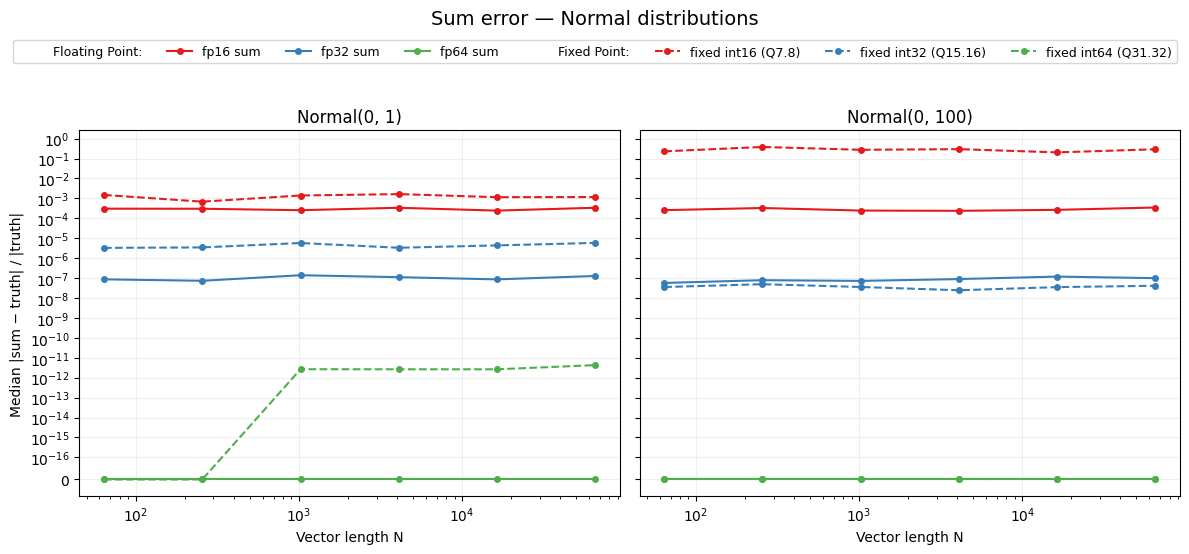

In [46]:
normal_configs = [
    ("Normal(0, 1)",
     lambda n: torch.randn(n, device="cuda", dtype=torch.float32)),
    ("Normal(0, 100)",
     lambda n: torch.randn(n, device="cuda", dtype=torch.float32) * 100),
]

run_benchmarks(normal_configs, "Sum error — Normal distributions")

## Uniform distributions

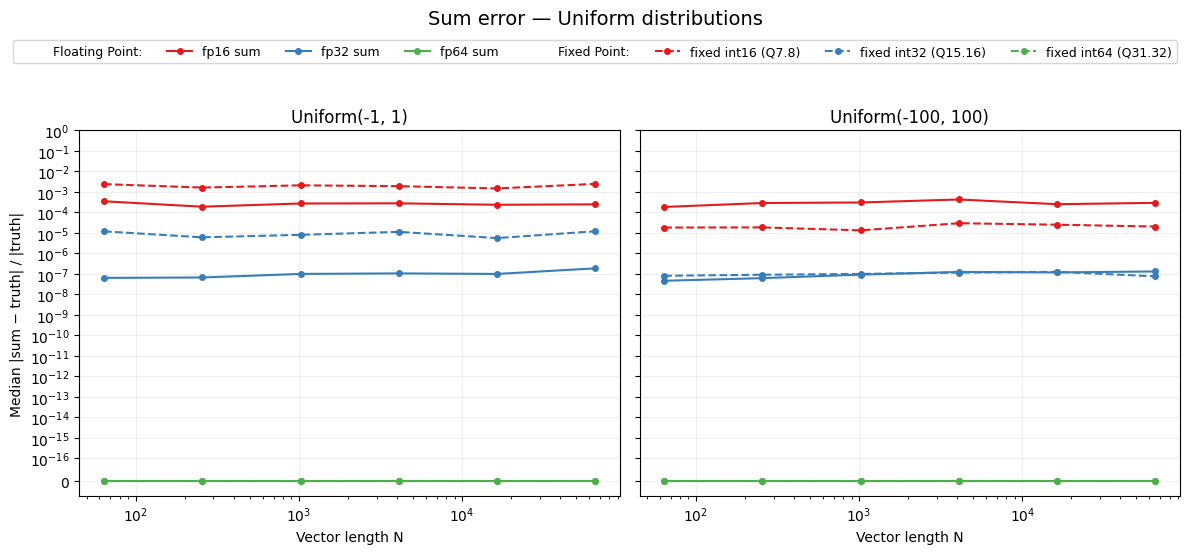

In [47]:
uniform_configs = [
    ("Uniform(-1, 1)",
     lambda n: torch.empty(n, device="cuda", dtype=torch.float32).uniform_(-1, 1)),
    ("Uniform(-100, 100)",
     lambda n: torch.empty(n, device="cuda", dtype=torch.float32).uniform_(-100, 100)),
]

run_benchmarks(uniform_configs, "Sum error — Uniform distributions")